# Рассмотрим работу линейной регрессии.

In [468]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.datasets import make_friedman1
from sklearn.metrics import mean_absolute_error as mse
%matplotlib inline

Выгрузим данные, выберем одну размерность.

In [469]:
a = make_friedman1(n_samples=300, n_features=5, noise=-3.0, random_state=None)

In [470]:
X, y = np.array(a[0][:,0]*0.05), a[1]*0.001
X_to_fit = X.reshape(X.shape[0],1) # для обучения моделей нужно преобразовать X

Изобразим данные.

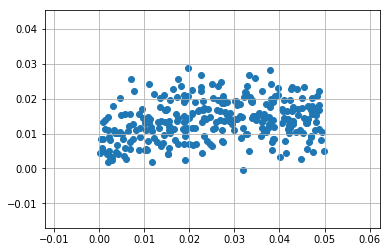

In [471]:
plt.scatter(X, y)
plt.grid()
plt.savefig("1.png")

Здесь очень явно прослеживает линейная зависимость, давайте ее вычислим.

In [472]:
model = LinearRegression(fit_intercept=False) # метод не возвращает нулевой к-т, поэтому без него работаем
model.fit(X_to_fit, y)
model.coef_ 

array([0.43476251])

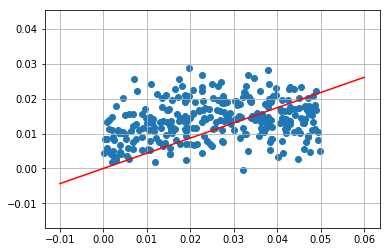

In [473]:
delta = np.linspace(-0.01, 0.06, 100)
plt.scatter(X, y)
plt.plot(delta, model.coef_*delta , color="r")
plt.grid()
plt.savefig("2.png")

Да, действительно, метод словил линейную зависимость.

## Но что, если?..

Увеличим одну точку, скажем, в 500 раз.

In [474]:
num_to_increase = 5000
y[0] = y[0]*num_to_increase


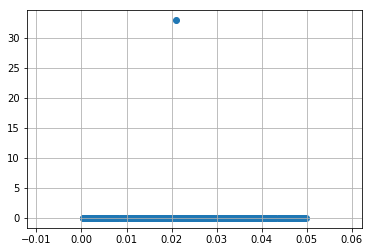

In [475]:
plt.scatter(X, y)
plt.grid()
plt.savefig("3.png")

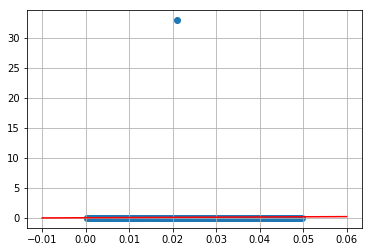

In [476]:
model = LinearRegression(fit_intercept=False)
model.fit(X_to_fit, y)

plt.scatter(X, y)
plt.plot(delta, model.coef_*delta, color="r")
plt.grid()
plt.savefig("4.png")

In [477]:
model.coef_

array([3.10404904])

Что это значит? Если изобразить данные без этой точки, то будет следующее:

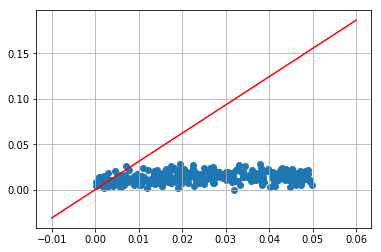

In [478]:
plt.scatter(X[1:], y[1:])
plt.plot(delta, model.coef_*delta, color="r")
plt.grid()

### Получается, одна плохая точка так сильно "испортила" линейную модель, и у нее не получается ловить линейные зывисимости в данных.

Но что будет, если применить регуляпризацию - то есть не позволить коэффициентам быть достаточно большими?

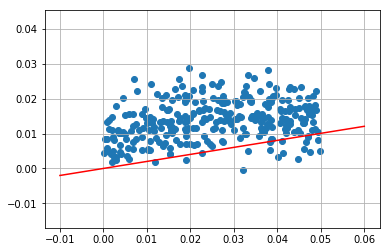

In [479]:
X, y = np.array(a[0][:,0]*0.05), a[1]*0.001
X_to_fit = X.reshape(X.shape[0],1) # для обучения моделей нужно преобразовать X

model = Ridge(fit_intercept=False, alpha=0.3)
model.fit(X_to_fit, y)

plt.scatter(X, y)
plt.plot(delta, model.coef_*delta, color="r")
plt.grid()
plt.savefig("4.png")

In [480]:
model.coef_

array([0.20094661])

In [481]:
y[0] = y[0]*num_to_increase

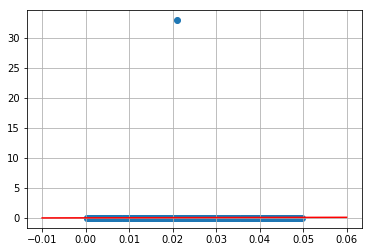

In [482]:
model.fit(X_to_fit, y)

plt.scatter(X, y)
plt.plot(delta, model.coef_*delta, color="r")
plt.grid()
plt.savefig("5.png")

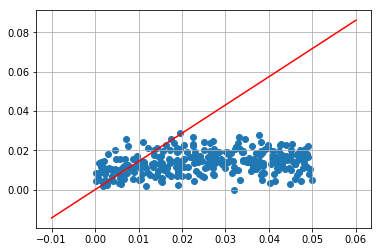

In [483]:
plt.scatter(X[1:], y[1:])
plt.plot(delta, model.coef_*delta, color="r")
plt.grid()

In [484]:
model.coef_

array([1.43468702])

## Практика

Попробуйте сами поиграться с регуляризацией - сгенерируйте свой датасет, используя функцию make_friedman, сгенерируйте что-нибудь линейное, обучите классификатор, посчитайте ошибку. Какое получилось качество? Что будет с классификатором, если добавить туда выбросов?

In [485]:
a = make_friedman1(n_samples=300, n_features=5, noise=-3.0, random_state=None)
X = a[0] # X
y = a[1] # y

model = LinearRegression()
model.fit(X[:200], y[:200])
mse(model.predict(X[200:]), y[200:])

###
# Ваш код здесь

###

2.9497640398692897